In [11]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [12]:
import sys
sys.path.append('..')

In [45]:
legends_df = pd.read_csv('data/class_legend.csv')

In [13]:
data_df = pd.read_csv('data/regionwise_yearwise_samples/DES_2024_v8.csv')

In [14]:
data_df.shape

(117387, 126)

In [15]:
all(data_df['lat'] == data_df['latitude'])

False

In [16]:
data_df[['lat','latitude']]

,lat,latitude
0,310564,31.056422
1,310564,31.056422
2,310561,31.056154
3,310561,31.056154
4,310561,31.056154
...,...,...
117382,209592,20.959269
117383,209589,20.958997
117384,209595,20.959536
117385,209595,20.959536


In [17]:
list(data_df.columns)

['system:index',
 'area_m2',
 'area_proportion',
 'aspect_cos',
 'aspect_sin',
 'bci_mad',
 'bci_median',
 'blue_mad',
 'blue_median',
 'blue_median_dry',
 'blue_median_wet',
 'blue_swing',
 'class',
 'elevation',
 'evi2_mad',
 'evi2_median',
 'evi2_median_dry',
 'evi2_median_wet',
 'evi2_swing',
 'green_mad',
 'green_median',
 'green_median_dry',
 'green_median_wet',
 'green_swing',
 'gv_mad',
 'gv_median',
 'gv_median_dry',
 'gv_median_wet',
 'gv_swing',
 'hand',
 'ibi_mad',
 'ibi_median',
 'lat',
 'latitude',
 'lon',
 'longitude',
 'mndwi_mad',
 'mndwi_median',
 'mndwi_median_dry',
 'mndwi_median_wet',
 'mndwi_swing',
 'mosaic_version',
 'ndfi_mad',
 'ndfi_median',
 'ndfi_median_dry',
 'ndfi_median_wet',
 'ndfi_swing',
 'ndmi_mad',
 'ndmi_median',
 'ndmi_median_dry',
 'ndmi_median_wet',
 'ndmi_swing',
 'ndvi_mad',
 'ndvi_median',
 'ndvi_median_dry',
 'ndvi_median_wet',
 'ndvi_p25',
 'ndvi_p75',
 'ndvi_q1_median',
 'ndvi_q2_median',
 'ndvi_q3_median',
 'ndvi_q4_median',
 'ndvi_swing'

In [18]:
data_gdf = gpd.GeoDataFrame(data_df,
                            geometry=gpd.points_from_xy(data_df['longitude'], 
                                                        data_df['latitude']),
    crs="EPSG:4326")

In [33]:
data_gdf.isna().sum()[data_gdf.isna().sum() > 0]

ndvi_q1_median    11065
ndvi_q2_median    10094
ndvi_q3_median       87
ndvi_q4_median     2415
q1_count          11065
q2_count          10094
q3_count             87
q4_count           2415
dtype: int64

In [40]:
[x for x in list(data_gdf.columns) if 'ndvi' in x]

['ndvi_mad',
 'ndvi_median',
 'ndvi_median_dry',
 'ndvi_median_wet',
 'ndvi_p25',
 'ndvi_p75',
 'ndvi_q1_median',
 'ndvi_q2_median',
 'ndvi_q3_median',
 'ndvi_q4_median',
 'ndvi_swing']

In [41]:
data_gdf.sample(n=1000).explore()

In [ ]:
cols_to_drop = ['class',
                'system:index',
                'area_m2',
                'area_proportion',
                'usable_count',
                '.geo',
                 'q1_count',
                'q2_count',
                'q3_count',
                'q4_count',
                'quarters_present',
                'latitude',
                'longitude',
                'geometry',
                'ndvi_q1_median',
                'ndvi_q2_median',
                'ndvi_q3_median',
                'ndvi_q4_median', #coz quarterly ndvi values have lot of NA values
                ]

In [43]:
X = data_gdf.drop(columns=cols_to_drop)
y = data_gdf['class']

/tmp/ipykernel_117201/596830776.py:19: UserWarning: The palette list has more values (20) than needed (16), which may not be intended.
  sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class",palette=palette, s=40, alpha=0.8, edgecolor="none")


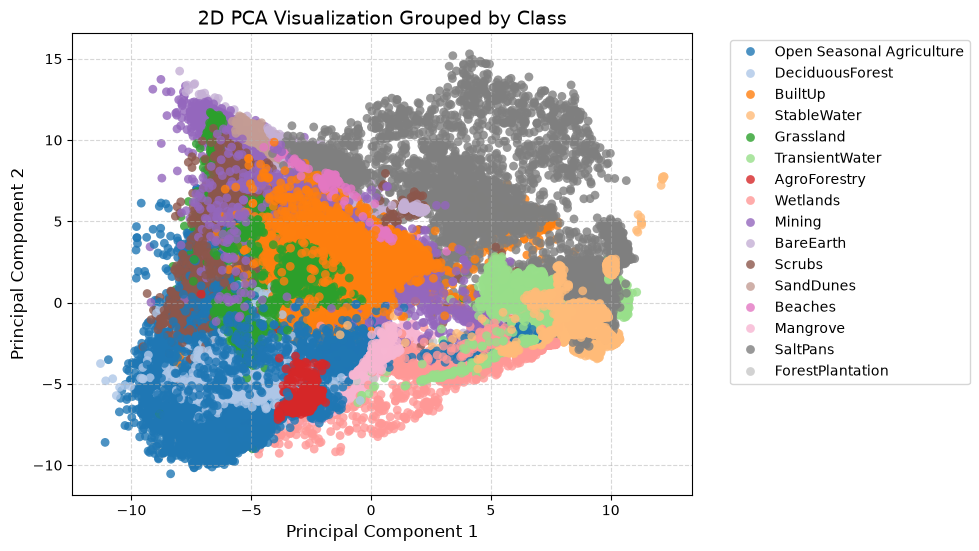

In [66]:
# --- 3. Standardize Features ---
# PCA is highly sensitive to variances of the initial variables.
X_scaled = StandardScaler().fit_transform(X)

# --- 4. Apply PCA ---
# Reduce features down to 2 principal components for 2D visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

# --- 5. Recombine Components and Labels into a New DataFrame ---
pca_df = pd.DataFrame(data=pca_features, columns=["PC1", "PC2"])
pca_df["Class"] = y.values  # Add the class labels back
pca_df["Class"] = pca_df["Class"].map(
    dict(zip(legends_df['class_code'],legends_df['class_name']))
)
palette = sns.color_palette("tab20", 20)
# --- 6. Plot the Result ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class",palette=palette, s=40, alpha=0.8, edgecolor="none")

# Optional adjustments to improve readability
plt.title("2D PCA Visualization Grouped by Class", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
# plt.legend(title="Class Labels")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.5)
plt.grid(True, linestyle="--", alpha=0.5)

Check correlation in features

In [ ]:
# correlation_matrix = X.corr(method='pearson')

In [70]:
threshold = 0.8
corr_matrix = X.corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Target correlations
target_corr = X.apply(lambda col: col.corr(y)).abs()

to_drop = set()
for col in upper.columns:
  # Find features correlated with 'col' above threshold
  correlated_features = upper.index[upper[col] > threshold].tolist()
  if correlated_features:
    for feat in correlated_features:
      # Compare target correlation and drop the weaker one
      if target_corr[feat] < target_corr[col]:
        to_drop.add(feat)
      else:
        to_drop.add(col)

/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [72]:
len(to_drop)

71

In [73]:
X.shape

(117387, 109)